In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [2]:
#plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)
plt.rc('text', usetex=True)

In [3]:
prediction_data_files = glob.glob('../Fe-Mo/results/PREDICTION__*')

In [4]:
PredictionValues = {}

In [5]:
for file in prediction_data_files:
    if 'old' in file:
        continue
    label, phase, model_with_params = file.replace('.csv','').split('__')
    PredictionValues[(model_with_params, phase)] = pd.read_csv(file, header=0, index_col=0)

In [6]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [7]:
BS = pd.read_pickle('../Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [8]:
import glob
import os

In [9]:
multiplicities = {'R': 11, 'M': 11, 'P': 12, 'delta': 14}
multiplicities

{'R': 11, 'M': 11, 'P': 12, 'delta': 14}

In [10]:
nats = {'R': 53, 'M': 52, 'P': 56, 'delta': 56}

In [11]:
inchull = {}
all_preds_files = {}

for phase in ['R', 'M', 'P', 'delta']:
    phase_chull_dir = f'../Fe-Mo/data/Validation/inchull/{phase}'
    list_file = os.path.join(phase_chull_dir, 'list.csv')

    # Start from the phase list as the base dataframe and keep only required columns.
    phase_df = pd.read_csv(list_file, index_col=0)
    keep_cols = [c for c in phase_df.columns if c == 'Fe_pv' or c.startswith('EF_')]
    phase_df = phase_df[keep_cols]

    # Find all prediction files for this phase.
    all_preds_files[phase] = sorted(
        glob.glob(os.path.join(phase_chull_dir, 'EF_nmhcp__*.csv'))
    )

    fe_sources = []
    if 'Fe_pv' in phase_df.columns:
        fe_sources.append(phase_df['Fe_pv'])

    for file in all_preds_files[phase]:
        pred_df = pd.read_csv(file, index_col=0)

        if 'Fe_pv' in pred_df.columns:
            fe_sources.append(pred_df['Fe_pv'])

        ef_cols = [c for c in pred_df.columns if c.startswith('EF_')]
        for col in ef_cols:
            if col in phase_df.columns:
                phase_df[col] = phase_df[col].combine_first(pred_df[col])
            else:
                phase_df = phase_df.join(pred_df[[col]], how='outer')

    if fe_sources:
        merged_fe = pd.concat(fe_sources, axis=1).bfill(axis=1).iloc[:, 0]
        phase_df['Fe_pv'] = merged_fe

    phase_df.index = phase_df.index.str.replace(f'Mo_sv{nats[phase]}.{phase}.NM', f'Mo_sv{nats[phase]}.{phase}-'+multiplicities[phase]*'B'+'.NM')
    phase_df.index = phase_df.index.str.replace(f'Fe_pv{nats[phase]}.{phase}.NM', f'Fe_pv{nats[phase]}.{phase}-'+multiplicities[phase]*'A'+'.NM')

    inchull[phase] = phase_df.sort_values(by='Fe_pv')

In [12]:
inchull['R']

,Fe_pv,EF_nmhcp__SOAP_specific_small,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE
Mo_sv53.R-BBBBBBBBBBB.NM,0.000000,0.301968,0.308823,0.307381
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.358491,NaN,0.056846,NaN
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,0.023066,NaN,0.026071
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,-0.041641,-0.031910,-0.037114
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,-0.023205,-0.013177,-0.021441
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,NaN,NaN,0.013287
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.735849,0.008024,NaN,NaN
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.735849,NaN,0.026118,NaN
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,NaN,0.066239,0.063679
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,0.084447,0.082851,0.086116


In [13]:
AtomsObjects  = {}
for phase in ['R', 'P','M', 'delta']:
    AtomsObjects[phase] = pd.read_pickle(f'../Fe-Mo/Atomsobjects/{phase}_structures.pkl')

In [14]:
composition = {}
for phase, atoms_obj in AtomsObjects.items():
    if isinstance(atoms_obj, pd.DataFrame):
        if 'atoms' in atoms_obj.columns:
            atoms_series = atoms_obj['atoms']
        elif atoms_obj.shape[1] == 1:
            atoms_series = atoms_obj.iloc[:, 0]
        else:
            raise ValueError(f"Cannot infer atoms column for phase '{phase}'")
    elif isinstance(atoms_obj, pd.Series):
        atoms_series = atoms_obj
    else:
        atoms_series = pd.Series(atoms_obj)

    composition[phase] = pd.DataFrame.from_dict(
        atoms_series.map(
            lambda a: {el: nel / len(a) for el, nel in a.symbols.formula.count().items()}
        ).to_dict(),
        orient='index'
    ).fillna(0)

# recover nans

In [15]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [16]:
keyname={
    'ACE': 'ACE_lmax=321',
    '0.7dprojections_0.5os':     '0.7dprojections_0.5os_16',
    'SOAP_specific_small':   'SOAP_specific_small_specific'

}

def bracket_value(v, ndigits=5):
    if pd.isna(v):
        return v
    if isinstance(v, str):
        s = v.strip()
        if s.startswith('[') and s.endswith(']'):
            return s
        num = pd.to_numeric(s, errors='coerce')
        return f'[{num:.{ndigits}f}]' if pd.notna(num) else s
    return f'[{float(v):.{ndigits}f}]'

In [17]:
for phase, chullpreds in inchull.items():
    for col in chullpreds.filter(regex='^EF').columns:
        modelname = col.replace('EF_nmhcp__', '')
        pred_key = (keyname.get(modelname), phase)
        src_col = 'EF_nmhcp__' + modelname

        if pred_key not in PredictionValues or src_col not in PredictionValues[pred_key].columns:
            continue

        mask = chullpreds[col].isna()
        fill_values = PredictionValues[pred_key][src_col].reindex(chullpreds.index)
        fill_values = fill_values.map(bracket_value)

        # Assign via .loc to avoid chained-assignment warnings.
        chullpreds[col] = chullpreds[col].astype('object')
        chullpreds.loc[mask, col] = fill_values.loc[mask]


# recover dft values

In [18]:

ValidationBS = pd.read_pickle('../validation_data/FullyCuratedParsedBriefSummary.pkl')

In [19]:
dft_files = sorted(glob.glob('../Fe-Mo/data/Validation/DFT_validation_inchull_*.csv'))

inchulldftval = {}
for file in dft_files:
    phase_name = os.path.basename(file).replace('DFT_validation_inchull_', '').replace('.csv', '')
    dft_df = pd.read_csv(file, index_col=0)

    # Apply the same index fix used for inchull.
    dft_df.index = dft_df.index.str.replace(
        f'Mo_sv{nats[phase_name]}.{phase_name}.NM',
        f"Mo_sv{nats[phase_name]}.{phase_name}-" + multiplicities[phase_name] * 'B' + '.NM'
    )
    dft_df.index = dft_df.index.str.replace(
        f'Fe_pv{nats[phase_name]}.{phase_name}.NM',
        f"Fe_pv{nats[phase_name]}.{phase_name}-" + multiplicities[phase_name] * 'A' + '.NM'
    )

    inchulldftval[phase_name] = dft_df

In [20]:
inchulldftval['R'].index[inchulldftval['R'].index.str.contains(r'Mo_sv53\.R-B+\.NM')]

Index(['Mo_sv53.R-BBBBBBBBBBB.NM'], dtype='object')

In [21]:
validation_intersection = {}
for phase, phasechull in inchull.items():
    validation_intersection[phase] = ValidationBS.index.intersection(phasechull.index)

In [22]:
validation_intersection['R']

Index(['Fe_pv39Mo_sv14.R-AAAAAABAABB.NM', 'Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM',
       'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM', 'Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM'],
      dtype='object')

In [23]:
BS.index[BS.index.str.contains('Fe_pv53')]

Index(['Fe_pv53.R.NM'], dtype='object')

In [24]:
BS.index = BS.index.str.replace('Fe_pv53.R.NM', f'Fe_pv53.R-{"A"*11}.NM')

In [25]:
BS.index = BS.index.str.replace('Mo_sv53.R.NM', f'Mo_sv53.R-{"B"*11}.NM')

In [26]:
BS.rename(columns={'Fe_pv': 'x_Fe', 'Mo_sv': 'x_Mo', 'EF_nmhcp': 'EF'}, inplace=True)

In [27]:
BS_intersection = {}
train_and_validation_samples = {}
for phase, chulldata in inchull.items():
    BS_intersection[phase] = BS.index.intersection(chulldata.index)
    train_and_validation_samples[phase] = BS_intersection[phase].append(validation_intersection[phase]).unique()

In [28]:
DFTBS = {}
for phase in inchull.keys():
    train_df = BS[['x_Fe', 'x_Mo', 'EF']].loc[BS_intersection[phase]]
    val_df = ValidationBS[['x_Fe', 'x_Mo', 'EF']].loc[validation_intersection[phase]]
    phase_dft = pd.concat([train_df, val_df], axis=0).sort_values(by='x_Mo')
    DFTBS[phase] = phase_dft.groupby(level=0).first()

In [29]:
pd.concat(DFTBS, axis = 0)

x_Fe      x_Mo        EF
R     Fe_pv19Mo_sv34.R-ABABAABBBBB.NM         0.358491  0.641509  0.058503
      Fe_pv21Mo_sv32.R-AAABAABBBBB.NM         0.396226  0.603774  0.023408
      Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM         0.509434  0.490566 -0.042841
      Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM         0.622642  0.377358 -0.023359
      Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM         0.716981  0.283019  0.022096
      Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM         0.735849  0.264151  0.028865
      Fe_pv39Mo_sv14.R-AAAAAABAABB.NM         0.735849  0.264151  0.006513
      Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM          0.849057  0.150943  0.063301
      Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM          0.886792  0.113208  0.082154
      Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM          0.943396  0.056604  0.136438
      Fe_pv53.R-AAAAAAAAAAA.NM                1.000000  0.000000  0.165564
      Mo_sv53.R-BBBBBBBBBBB.NM                0.000000  1.000000  0.307507
M     Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM         0.384615  0.615385  0.056906
      Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM         0.461538  0.538462  -0.00965
      Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM         0.538462  0.461538 -0.039529
      Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM         0.615385  0.384615 -0.025804
      Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM         0.692308  0.307692  0.018557
      Fe_pv40Mo_sv12.M-AAAAAAABABB.NM         0.769231  0.230769  0.054827
      Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM          0.846154  0.153846  0.102519
      Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM          0.923077  0.076923  0.158369
P     Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM        0.214286  0.785714  0.100678
      Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM        0.285714  0.714286  0.069467
      Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM        0.357143  0.642857  0.024169
      Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM        0.428571  0.571429 -0.003918
      Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM        0.500000  0.500000  0.022298
      Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM        0.571429  0.428571  0.056368
      Fe_pv40Mo_sv16.P-AAABBBAAABAA.NM        0.714286  0.285714   0.06994
      Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM         0.928571  0.071429  0.141497
      Fe_pv52Mo_sv4.P-AAAABAAAAAAA.NM         0.928571  0.071429  0.149164
      Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM         0.142857  0.857143  0.144182
delta Fe_pv16Mo_sv40.delta-BBBBBBBBABAAAB.NM  0.285714  0.714286  0.070615
      Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM  0.285714  0.714286  0.062955
      Fe_pv20Mo_sv36.delta-BBBBBBBBAAAAAB.NM  0.357143  0.642857  0.043339
      Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM  0.357143  0.642857   0.04232
      Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM  0.428571  0.571429  0.043246
      Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM  0.428571  0.571429 -0.003743
      Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM  0.500000  0.500000  0.007117
      Fe_pv28Mo_sv28.delta-BBBBBBBAAAAAAA.NM  0.500000  0.500000  0.022701
      Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM  0.571429  0.428571  0.020276
      Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM  0.642857  0.357143  0.036654
      Fe_pv36Mo_sv20.delta-BBBBBAAAAAAAAA.NM  0.642857  0.357143  0.033365
      Fe_pv44Mo_sv12.delta-AABBBAAAAAAAAA.NM  0.785714  0.214286  0.068263
      Fe_pv44Mo_sv12.delta-BBBAAAAAAAAAAA.NM  0.785714  0.214286   0.06865
      Fe_pv48Mo_sv8.delta-AABABAAAAAAAAA.NM   0.857143  0.142857  0.096918
      Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM   0.857143  0.142857   0.08805
      Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM   0.857143  0.142857  0.108389
      Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM   0.928571  0.071429  0.120397
      Fe_pv52Mo_sv4.delta-BAAAAAAAAAAAAA.NM   0.928571  0.071429  0.140937
      Fe_pv56.delta-AAAAAAAAAAAAAA.NM         1.000000  0.000000  0.171448
      Mo_sv56.delta-BBBBBBBBBBBBBB.NM         0.000000  1.000000  0.257766

In [30]:
for phase, phasedf in inchull.items():
    # Merge DFT EF values into the phase dataframe.
    if 'EF' not in phasedf.columns:
        phasedf = pd.concat([phasedf, DFTBS[phase]['EF']], axis=1)
    else:
        phasedf['EF'] = phasedf['EF'].combine_first(DFTBS[phase]['EF'])

    # Bracket EF values for structures not present in the phase DFT-chull table.
    chull_idx = inchulldftval[phase].index
    mask = ~phasedf.index.isin(chull_idx)
    phasedf.loc[mask, 'EF'] = phasedf.loc[mask, 'EF'].map(bracket_value)
    phasedf = phasedf.rename(columns={'Fe_pv': 'Fe'})
    phasedf['Mo'] = 1- phasedf['Fe']
    inchull[phase] = phasedf


In [31]:
for phase, phasechull in inchull.items():
    newindex = phasechull.index.str.split('.').map(lambda i: i[1]) #.to_frame()
    phasechull.index = newindex

# format columns

In [32]:
table_to_save = {}
for phase, table in inchull.items():
    table_to_save[phase] = table.rename(columns={'Fe_pv': '$x_{Fe}$', 'Mo_sv': '$x_{Mo}$', 'EF_nmhcp__0.7dprojections_0.5os': 'BOP', 'EF_nmhcp__ACE':  'ACE', 'EF_nmhcp__SOAP_specific_small': 'SOAP', 'EF': 'DFT' })

In [33]:
import re
import numpy as np

def _fmt3(v):
    if pd.isna(v):
        return ''
    if isinstance(v, (int, float, np.integer, np.floating)):
        return f'{float(v):.3f}'
    if isinstance(v, str):
        s = v.strip()
        m = re.fullmatch(r'\[([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\]', s)
        if m:
            return f'[{float(m.group(1)):.3f}]'
        if re.fullmatch(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s):
            return f'{float(s):.3f}'
        return s
    return str(v)

for phase, table in table_to_save.items():
    table.to_latex(
        f'chull_samples_table_{phase}.tex',
        formatters={col: _fmt3 for col in table.columns},
        column_format='l|c|c|c|c|c|c|',
    )

In [34]:
figw, figh = plt.rcParams['figure.figsize']

In [35]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [36]:
PredictionValues[('SOAP_specific_small_specific', 'R')]['EF_nmhcp__SOAP_specific_small']

Fe_pv53.R.NM                      0.168424
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    0.084447
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    0.141029
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    0.066100
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    0.127103
                                    ...   
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    0.411631
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    0.448679
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    0.339790
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    0.414142
Mo_sv53.R.NM                      0.301968
Name: EF_nmhcp__SOAP_specific_small, Length: 2048, dtype: float64

In [37]:
figw, figh = plt.rcParams['figure.figsize']

In [40]:
def plot_tagged_chull(
    chull_df,
    fname,
    figw,
    figh,
    output_dir='../Fe-Mo/graphs',
    prefix='Fe-Mo_tagged_chull',
    ax=None,
    save=True,
    plot_line=True,
    line_kwargs=None,
    tag_rotation=90,
    tag_position='auto',
    x_pad_frac=0.05,
    y_pad_frac=0.08,
):
    raw_values = chull_df[fname].astype(str).str.strip()
    is_bracketed = raw_values.str.match(r'^\[.*\]$')
    plot_values = pd.to_numeric(raw_values.where(~is_bracketed), errors='coerce')
    valid = plot_values.notna() & chull_df['Mo'].notna()
    plot_df = pd.DataFrame({
        'x': chull_df.loc[valid, 'Mo'],
        'y': plot_values.loc[valid],
    })
    idx_keep = plot_df.groupby('x')['y'].idxmin()
    plot_df = plot_df.loc[idx_keep].sort_values('x')

    if isinstance(tag_rotation, str):
        rotation_map = {'vertical': 90, 'horizontal': 0}
        tag_rotation = rotation_map.get(tag_rotation.lower(), tag_rotation)

    if isinstance(tag_position, str):
        pos = tag_position.lower().strip()
        tag_position_map = {
            'auto': 'auto',
            'above': 'above',
            'over': 'above',
            'force above': 'above',
            'force_above': 'above',
            'below': 'below',
            'under': 'below',
            'force below': 'below',
            'force_below': 'below',
        }
        tag_position = tag_position_map.get(pos, pos)

    if tag_position not in {'auto', 'above', 'below'}:
        raise ValueError("tag_position must be one of: 'auto', 'above', 'below'")

    ymean = plot_df['y'].mean()
    y_span = max(plot_df['y'].max() - plot_df['y'].min(), 1e-6)
    x_span = max(plot_df['x'].max() - plot_df['x'].min(), 1e-6)
    dy_mag = max(0.01, 0.03 * y_span)

    created_ax = ax is None
    if created_ax:
        fig, ax = plt.subplots(figsize=(figw * 1.35, figh * 1.35))
    else:
        fig = ax.figure

    ax.scatter(plot_df['x'], plot_df['y'], zorder=3)
    if plot_line:
        if line_kwargs is None:
            line_kwargs = {}
        default_line_kwargs = {'linewidth': 1.5, 'alpha': 0.9, 'zorder': 2}
        default_line_kwargs.update(line_kwargs)
        ax.plot(plot_df['x'], plot_df['y'], **default_line_kwargs)

    has_above_tags = False
    has_below_tags = False
    for index, row in plot_df.iterrows():
        tag = index.split('-')[-1].split('.')[0]
        x = row['x']
        y = row['y']

        if tag_position == 'above':
            thealign = 'bottom'
            dy = dy_mag
            has_above_tags = True
        elif tag_position == 'below':
            thealign = 'top'
            dy = -dy_mag
            has_below_tags = True
        else:
            if y > ymean:
                thealign = 'top'
                dy = -dy_mag
                has_below_tags = True
            else:
                thealign = 'bottom'
                dy = dy_mag
                has_above_tags = True

        ax.text(
            x=x,
            y=y + dy,
            s=tag,
            verticalalignment=thealign,
            rotation=tag_rotation,
            fontsize=13,
            zorder=4,
        )

    # Adaptive axis padding keeps both points and offset tags visible across phases.
    x_pad = max(0.01, x_pad_frac * x_span)
    y_pad = max(0.02, y_pad_frac * y_span, 1.2 * dy_mag)

    # Vertical labels need extra room to avoid overlap with axes labels.
    is_vertical_labels = isinstance(tag_rotation, (int, float)) and (abs(tag_rotation) % 180 == 90)
    if is_vertical_labels and has_below_tags:
        y_pad = max(y_pad, 0.40 * y_span)
    if is_vertical_labels and has_above_tags:
        y_pad = max(y_pad, 0.20 * y_span)

    xmin = plot_df['x'].min() - x_pad
    xmax = plot_df['x'].max() + x_pad
    ymin = plot_df['y'].min() - y_pad
    ymax = plot_df['y'].max() + y_pad

    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    ax.set_xlabel('$x_{Mo}$', labelpad=10)
    ax.set_ylabel('$\\Delta E_F$ (eV/atom)')
    title = 'DFT' if fname == 'EF' else fname.split('__')[-1]
    ax.set_title(title)

    if created_ax:
        fig.tight_layout()

    outpath = None
    if save:
        safe_fname = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in fname)
        outpath = f'{output_dir}/{prefix}_{safe_fname}.pdf'
        fig.savefig(outpath)

    return fig, ax, outpath

In [41]:
plt.rc('text', usetex=False)

In [42]:
table_to_save['R']

,Fe,SOAP,BOP,ACE,DFT,Mo
R-BBBBBBBBBBB,0.000000,0.301968,0.308823,0.307381,0.307507,1.000000
R-ABABAABBBBB,0.358491,[0.05288],0.056846,[0.06496],[0.05850],0.641509
R-AAABAABBBBB,0.396226,0.023066,[0.03950],0.026071,0.023408,0.603774
R-AAAAAABBBBB,0.509434,-0.041641,-0.03191,-0.037114,-0.042841,0.490566
R-AAAAAAABBBB,0.622642,-0.023205,-0.013177,-0.021441,-0.023359,0.377358
R-BAAAAAAABBB,0.716981,[0.02757],[0.02351],0.013287,[0.02210],0.283019
R-AAAAAABAABB,0.735849,0.008024,[0.02756],[0.03121],0.006513,0.264151
R-AAAAAAAABBB,0.735849,[0.02885],0.026118,[0.02719],[0.02886],0.264151
R-AAAAAAAAABB,0.849057,[0.06610],0.066239,0.063679,[0.06330],0.150943
R-AAAAAAAAAAB,0.886792,0.084447,0.082851,0.086116,0.082154,0.113208


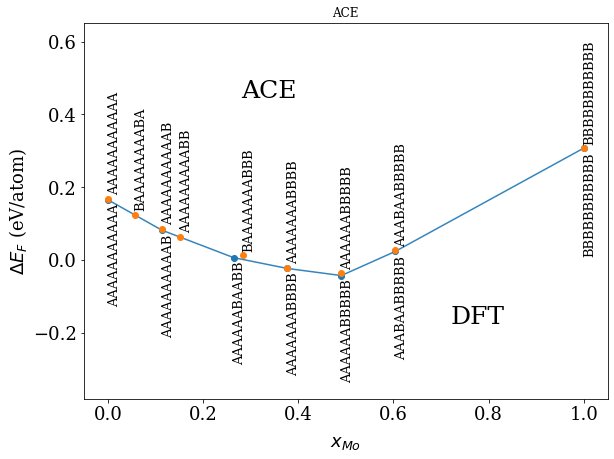

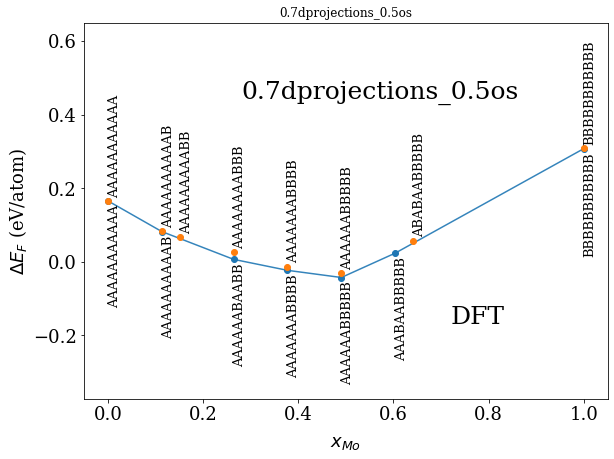

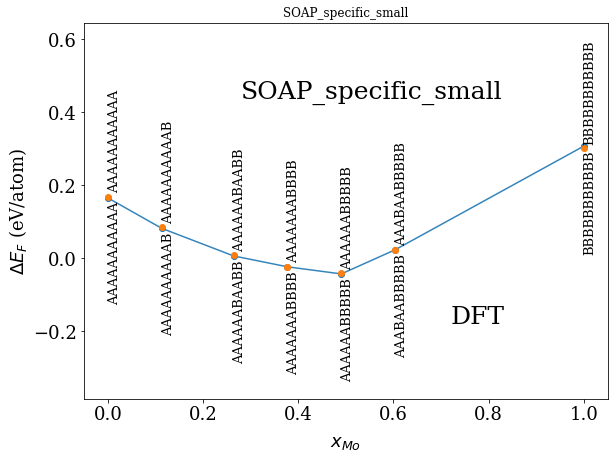

In [61]:
fname = 'EF'
for fname_comp in [ 'EF_nmhcp__ACE', 'EF_nmhcp__0.7dprojections_0.5os',  'EF_nmhcp__SOAP_specific_small']:
    fig, ax, saved_path = plot_tagged_chull(inchull['R'], fname, figw, figh, tag_position='below' )
    fig, ax, saved_path = plot_tagged_chull(inchull['R'], fname_comp, figw, figh, plot_line=False, tag_position='above', ax=ax, y_pad_frac=1)
    ax.annotate('DFT', (0.7, 0.2), xycoords='axes fraction', fontsize=25)
    ax.annotate(fname_comp.split('__')[-1], (0.3, 0.8), xycoords='axes fraction', fontsize=25)
    saved_path